<a href="https://colab.research.google.com/github/DanielBR0612/supervised-machine-learning/blob/main/atividade_2.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade Prática**
<font size=3>

- **Tema:** métodos probabilísticos.
- **Prazo de entrega:** 07 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **1. Questão:**
<font size=3>

Com base no *dataset* de [Cogumelos](https://www.kaggle.com/datasets/uciml/mushroom-classification), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:
1. Avalie qual tipo de método **_Naive Bayes_** é mais apropriado para realizar a tarefa de classificação dos dados (ver **_notebook_ 9**). **Justifique** sua resposta em uma **célula _markdown_**;
2. Utilize as funções [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) e [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável de atributos (`X`) e alvo (`y`). Utilize [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) caso ache necessário;
3. Treine seu modelo com [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) a fim de ajustar seu(s) hiperparâmetro(s);
4. Realize predições e avaliaçãoes do modelo com dados de teste;
5. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
   

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import CategoricalNB, MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [75]:
cogumelos = pd.read_csv('/content/drive/MyDrive/dataset/mushrooms.csv')

O método Naive Bayes mais apropriado para realizar a tarfea de classificação dos dados dos cogumelos é o Categorical NB, ja que todos os dados do dataset são categóricos e discretos.

In [76]:
y_cogumelo = cogumelos["class"]
X_cogumelo = cogumelos.drop(["class"], axis=1)

le = LabelEncoder()
y_cogumelo_encoded = le.fit_transform(y_cogumelo)

X_train_cogumelo, X_dev_cogumelo, y_train_cogumelo, y_dev_cogumelo = train_test_split(X_cogumelo, y_cogumelo_encoded, test_size=0.4, stratify=y_cogumelo_encoded, random_state=42)
X_val_cogumelo, X_test_cogumelo, y_val_cogumelo, y_test_cogumelo = train_test_split(X_dev_cogumelo, y_dev_cogumelo, test_size=0.5, stratify=y_dev_cogumelo, random_state=42)

In [77]:
pipeline_nb = Pipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('nb', CategoricalNB())
])

In [78]:
parametros_grid = {
    'nb__alpha': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid_nb = GridSearchCV(pipeline_nb, parametros_grid, cv=5, scoring='accuracy')

grid_nb.fit(X_train_cogumelo, y_train_cogumelo)

print(f"Melhor parâmetro encontrado: {grid_nb.best_params_}")

Melhor parâmetro encontrado: {'nb__alpha': 0.1}



--- Relatório de Classificação ---
              precision    recall  f1-score   support

           e       0.97      1.00      0.98       842
           p       1.00      0.96      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



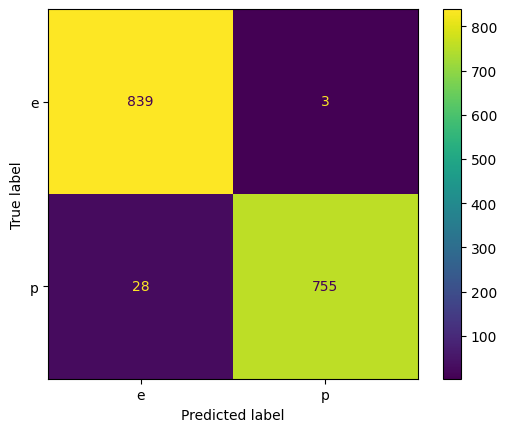

In [79]:
y_pred_cogumelo = grid_nb.predict(X_test_cogumelo)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test_cogumelo, y_pred_cogumelo, target_names=le.classes_))

cm = confusion_matrix(y_test_cogumelo, y_pred_cogumelo)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot()
plt.show()

Avaliando os resultados do modelo nesse dataset, podemos ver que apesar de ter uma acuracia alta, o recall da classe 'p' indica que 4% dos cogumelos venenosos passaram despercebidos, sendo falso negativo. E tambem o precision da classe 'e' indica que 3% dos cogumelos que o modelo julgou ser comestivel, tambem eram venenosos, tambem sendo falso negativo. No entanto, o modelo acertou com muita precisão os cogumelos que são de fato venenoso (precision 'p')

### **2. Questão:**
<font size=3>

Com base no *dataset* de [Spams](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:
1. Importe os *dataset* atribuindo à variável `encoding = 'latin-1'` na função `read_csv()`, a fim de importar corretamente os dados textuais;
2. Avalie qual tipo de método **_Naive Bayes_** é mais apropriado para realizar a tarefa de classificação dos dados (ver **_notebook_ 9**). **Justifique** sua resposta em uma **célula _markdown_**;
3. Defina os dados de **_spam_** e **_ham_** (não spam) como a variável alvo, e os dados textuais como a variável de atributos;
4. Utilize o [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) para processar os dados textuais e [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo. Utilize [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) caso ache necessário;
5. Treine seu modelo com [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) a fim de ajustar seu(s) hiperparâmetro(s);
6. Realize predições e avaliaçãoes do modelo com dados de teste;
7. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
    

In [80]:
from sklearn.feature_extraction.text import CountVectorizer


In [81]:
spams = pd.read_csv('/content/drive/MyDrive/dataset/spam.csv', encoding = 'latin-1')
spams

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [82]:
spams = spams.drop(spams.columns[spams.columns.str.contains('unnamed', case=False)], axis=1)
spams

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [83]:
y_spam = spams["v1"]
X_spam = spams["v2"]

le_spam = LabelEncoder()
y_spam_encoded = le.fit_transform(y_spam)

X_train_spam, X_dev_spam, y_train_spam, y_dev_spam = train_test_split(X_spam, y_spam_encoded, test_size=0.4, stratify=y_spam_encoded, random_state=42)
X_val_spam, X_test_spam, y_val_spam, y_test_spam = train_test_split(X_dev_spam, y_dev_spam, test_size=0.5, stratify=y_dev_spam, random_state=42)

Foi escolhido o MultinomialNB pois o dataset contem dados de texto não categóricos.

In [84]:
pipeline_spam_nb = Pipeline([
    ('encoder', CountVectorizer()),
    ('nb', MultinomialNB())
])

In [85]:
param_grid = {
    'nb__alpha': [0.1, 0.5, 1, 3, 5, 7, 9, 11, 13, 15]
}

grid_spam_nb = GridSearchCV(pipeline_spam_nb, param_grid, cv=5, scoring='accuracy')

grid_spam_nb.fit(X_train_spam, y_train_spam)

print(f"Melhor parâmetro encontrado: {grid_spam_nb.best_params_}")

Melhor parâmetro encontrado: {'nb__alpha': 0.5}



--- Relatório de Classificação ---
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       965
        spam       0.97      0.96      0.97       150

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



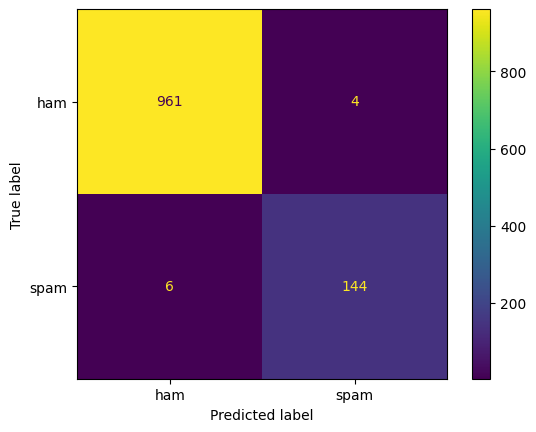

In [86]:
y_pred_spam = grid_spam_nb.predict(X_test_spam)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test_spam, y_pred_spam, target_names=le.classes_))

cm_spam = confusion_matrix(y_test_spam, y_pred_spam)
disp_spam = ConfusionMatrixDisplay(confusion_matrix=cm_spam, display_labels=le.classes_)

disp_spam.plot()
plt.show()

O modelo obteve ótimos resultados, tendo apenas 4 falsos positivos e 6 falsos negativo, sendo ham = positivo e spam = negativo.  